In [12]:
# Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: 
# önce basit ifade (32:10 - 51:10), sonra tek bir neuron. Neuron örneğinde tanh'ı Value'ya ekleyeceksin. Chain rule'u burada içselleştireceksin. (52:52 - 1:09:02)

In [28]:
import math
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data   
        self.grad = 0.0    #başlangıçta etkilememek için 0 verildi.
        self._prev = set(_children) 
        self._op = _op 
        self.label = label # önceki oluşturduğumuzdan farklı olarak tamamen görmek için eklenmiş label. 

    def __repr__(self):
        return f"Value(data={self.data})"  
    
    def __add__(self, other):  
        return Value(self.data + other.data, (self, other), '+')   
    
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*') 

    def __sub__(self,other):
        return Value(self.data - other.data, (self, other), '-')

    def __truediv__(self, other):
        return Value(self.data / other.data, (self, other), '/')

    def tanh(self): #aktivasyon fonksiyonu olarak -1 ile 1 arasona sıkıştırır.
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        return out


In [14]:
# Bir örnek yapalım 
a = Value(2,label='a') 
b = Value(3,label='b')
c = Value(7,label='c')
d = a + b * c ;  d.label = 'd'
e = d * a ; e.label = 'e'
e

Value(data=46)

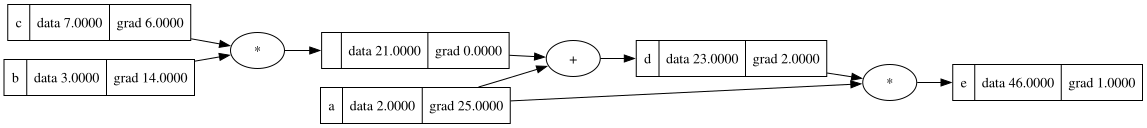

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record') 
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(e)

In [ ]:
def find():
    h = 0.0001

    a = Value(2, label='a')
    b = Value(3, label='b')
    c = Value(7, label='c')
    d = a + b * c;  d.label = 'd' # 23 unutmamak için yazdım 
    e = d * a;       e.label = 'e' # 46 

    L1 = e.data         

    a = Value(2 + h, label='a')
    b = Value(3, label='b')
    c = Value(7, label='c')
    d = a + b * c;  d.label = 'd'
    e = d * a;       e.label = 'e'

    L2 = e.data           

    print((L2 - L1) / h)

find()
# a.grad = 25

25.00010000005659


In [ ]:
e.grad = 1.0 
# e = d * a 
# de/dd = a # e nin d ye göre türevi 
# de/da = d # e nin a ya göre türevi 
# (f(x+h)-f(x))/h bu türevin tanımı  buradaki f(x+h) ->  f(d + h )* a yani d yi h kadar artırısak  - f(x) ise - f(d * a) yani (f(d + h) * a - f(d * a)) / h 
# d.grad = de/dd = a.data = 2 
d.grad = 2
a.grad = 25 # katkı_1 = de/da sadece e = d * a formülünden = d.data = 23 , katkı_2 = sadece d = a+b*c formülünden = d.grad * (dd/da) = 2 * 1 = 2  yani 23 + 2  = 25 
b.grad = 14 # d = a + b * c yani b ye göre türevi c.data = 7 + ikinci katkıdan   d.grad * de/db  = 2 * 7 = 14 
c.grad = 6 # d = a + b * c yani c ye göre türevi b.data  = 3 ikinci katkısı  d.grad * de/dc = 2 * 3 = 6
# yeni_a = 2.0001
# yeni_d = yeni_a + b*c = 2.0001 + 21 = 23.0001
# yeni_e = yeni_d * yeni_a = 23.0001 * 2.0001 = 46.00250001
# (46.00250001 - 46) / 0.0001 = 25.0001


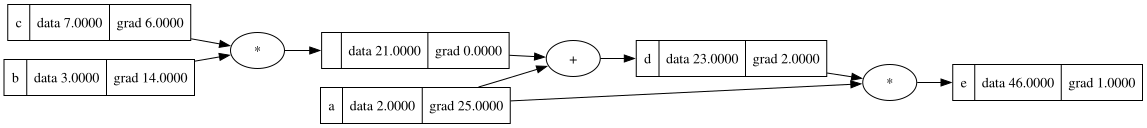

In [ ]:
draw_dot(e)

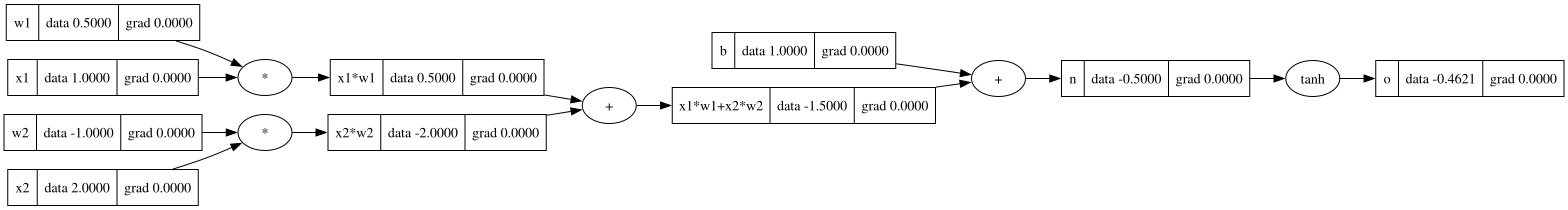

In [ ]:
x1 = Value(1.0 , label = 'x1')
x2 = Value(2.0, label = 'x2')

w1 = Value(0.5, label = 'w1')
w2 = Value(-1.0 , label = 'w2')

b = Value(1.0 , label  = 'b' ) 

#1 nöron n = x1*w1 + x2 * w2 + b 

x1w1 = x1*w1 ;  x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label  ='x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1+x2*w2'

n = x1w1x2w2 + b ; n.label = 'n'

o = n.tanh(); o.label = 'o' 
draw_dot(o)

0.7884


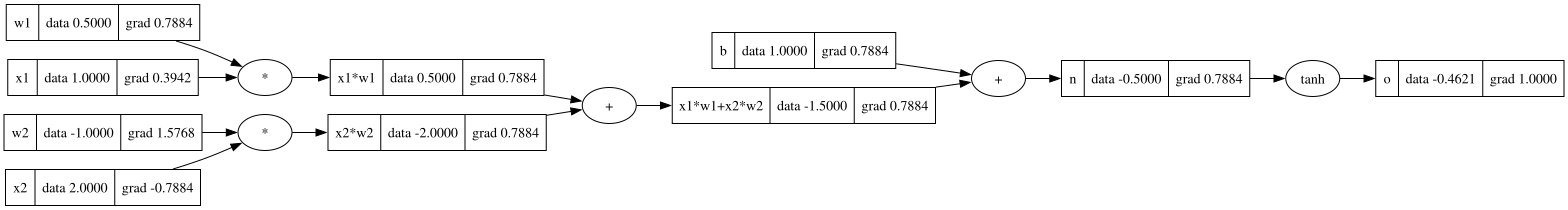

In [ ]:
# en sondaki noda bakarsak 
o.grad = 1.0 #do/do 
n.grad =  o.grad * (1 - o.data**2) #do/dn 
n.grad = 1.0 * (1 - (-0.46)**2)    #0.7884
print(n.grad)
#dn / dx1w1x2w2  1.0
#dn / db   1.0
#x1w1x2w2.grad = n.grad * (dn / dx1w1x2w2)
x1w1x2w2.grad = 0.7884 * 1.0 #0.7884
# b.grad = n.grad * (dn / db)
b.grad = 0.7884 * 1.0 
#x1w1x2w2 + b = n bu da dn/x1w1x2w2 ve dn / db 

#x1w1 + x2w2  = x1w1x2w2  dx1w1x2w2 / dx1w1  = 1.0  ve dx1w1x2w2 / dx2w2 = 1.0
x1w1.grad = x1w1x2w2.grad * 1.0 #0.7884
x2w2.grad = x1w1x2w2.grad * 1.0 #0.7884
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data *x2w2.grad
x1.grad = w1.data  * x1w1.grad
x2.grad = w2.data * x2w2.grad 
draw_dot(o)

